# CALC

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
N = 4


def W(n):
    return sp.E**(-2*sp.pi*sp.I*n/N)


# Term by term construction
wMatrix = sp.Matrix([
    [W(0*0), W(0*1), W(0*2), W(0*3)],
    [W(1*0), W(1*1), W(1*2), W(1*3)],
    [W(2*0), W(2*1), W(2*2), W(2*3)],
    [W(3*0), W(3*1), W(3*2), W(3*3)]
])
# wMatrix = sp.Matrix([[W(i * j) for j in range(N)] for i in range(N)])

display(wMatrix)

Matrix([
[1,  1,  1,  1],
[1, -I, -1,  I],
[1, -1,  1, -1],
[1,  I, -1, -I]])

In [6]:
# Define the x-values from 0 to 5 with 5 points
yPlot = [3,3,3,3]
# for n in range(N):
#     yPlot[n] = f(n)

fx = "scalon"

print(yPlot)

[3, 3, 3, 3]


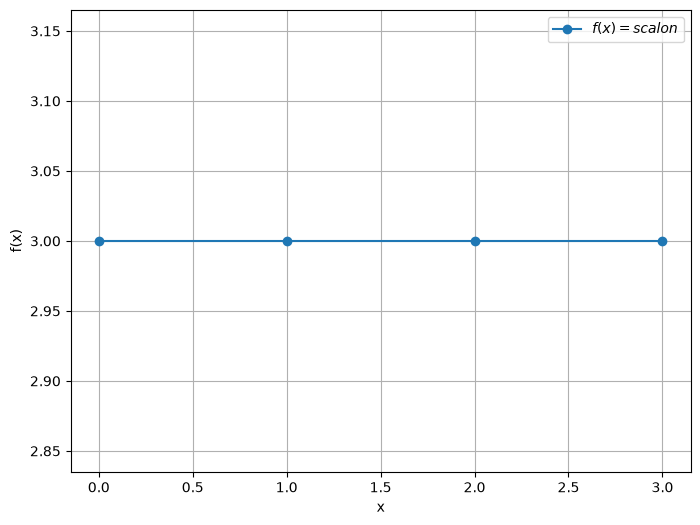

In [8]:
# Plot the function
# y axis to 0
plt.figure(figsize=(8, 6))
plt.plot(yPlot, 'o-', label=f'$f(x) = {fx}$') # 'o-' to show points and lines
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
x = sp.Matrix(yPlot) # Convert the list yPlot into a SymPy Matrix
X = wMatrix * x /N
# Sum the rows of the resulting matrix X
row_sums = np.sum(X, axis=1)
display(row_sums)

array([3, 0, 0, 0], dtype=object)

/tmp/ipykernel_23550/2932926750.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


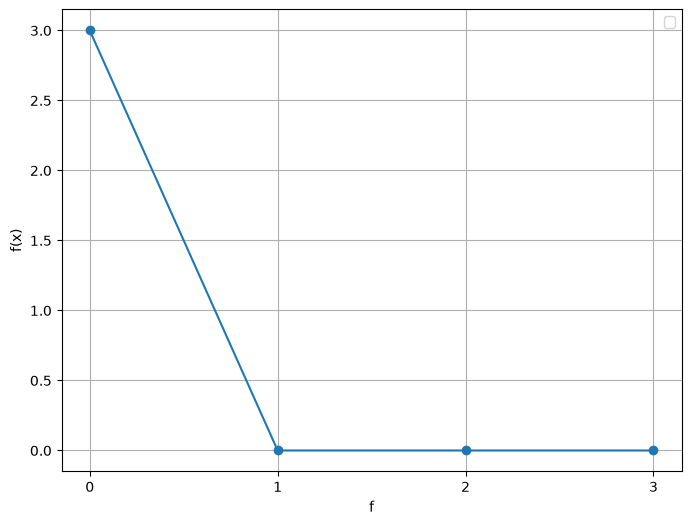

In [12]:
# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(row_sums, 'o-') # 'o-' to show points and lines
plt.xlabel('f')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.xticks(xPlot) # Set x-axis ticks to the specified points
plt.show()

# Visualizador

In [6]:
"""
dft_visualizador.py
--------------------
Calcula la DFT de una señal discreta usando la matriz de kernel W_N^(nk)
(tal como se plantea en el documento: X = W * x), y grafica:
    1) La señal de entrada x[n]  (dominio del tiempo/muestras)
    2) Parte real e imaginaria de X[k]
    3) Espectro de magnitud |X[k]|
    4) Espectro de fase phi_k = atan2(Im, Re)

También verifica el resultado contra numpy.fft.fft para confirmar que
la matriz W_N está bien construida.

Uso:
    python3 dft_visualizador.py
"""

import numpy as np
import matplotlib.pyplot as plt

PATH = "src/"

def construir_matriz_dft(N: int) -> np.ndarray:
    """
    Construye la matriz de kernel W_N de tamaño NxN, donde:

        W_N[n, k] = W_N^(n*k) = exp(-2j*pi*n*k / N)

    Esta es exactamente la matriz que aparece en el documento:

        [X[0]]   [W^0 W^0 W^0 W^0] [x[0]]
        [X[1]] = [W^0 W^1 W^2 W^3] [x[1]]
        [X[2]]   [W^0 W^2 W^4 W^6] [x[2]]
        [X[3]]   [W^0 W^3 W^6 W^9] [x[3]]
    """
    n = np.arange(N).reshape(-1, 1)   # columna
    k = np.arange(N).reshape(1, -1)   # fila
    W = np.exp(-2j * np.pi * n * k / N)
    return W


def calcular_dft(x: np.ndarray) -> np.ndarray:
    """
    Calcula X = W_N * x usando la matriz de kernel explícita.
    """
    N = len(x)
    W = construir_matriz_dft(N)
    X = W @ x
    return X


def graficar_dft(x, titulo="Señal", nombre_archivo=None):
    """
    Grafica en una sola figura de 4 paneles:
        - Señal de entrada x[n]
        - Re{X[k]} e Im{X[k]}
        - Magnitud |X[k]|
        - Fase phi_k (en radianes, también se marca en múltiplos de pi)
    """
    x = np.array(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = np.arange(N)

    # --- Cálculo con matriz explícita (pedagógico) ---
    X = calcular_dft(x)/N

    # --- Verificación contra numpy.fft (debe coincidir) ---
    X_np = np.fft.fft(x)
    error = np.max(np.abs(X - X_np))
    print(f"[{titulo}] Error máximo vs numpy.fft: {error:.2e}")

    magnitud = np.abs(X)
    fase = np.angle(X)  # radianes, rango (-pi, pi]

    # Umbral para no mostrar fase de componentes ~0 (ruido numérico)
    UMBRAL = 1e-9
    fase_mostrar = np.where(magnitud > UMBRAL, fase, 0.0)

    # In Plot
    # 1) Señal de entrada (parte real, que es lo físico) ---------------
    plt.figure(figsize=(6, 4))
    plt.title(f"Análisis DFT (N={N}) — {titulo}", fontsize =14, fontweight="bold")
    ax = plt.gca()
    ax.stem(n, x.real)
    ax.set_title("Entrada x[n]")
    ax.set_xlabel("n (muestra)")
    ax.set_ylabel("x[n]")
    ax.grid(True, alpha=0.3)

    plt.show()

    fig, axs = plt.subplots(2, 2, figsize=(11, 8))
    fig.suptitle(f"Análisis DFT (N={N}) — {titulo}", fontsize=14, fontweight="bold")

    # 1) Señal de entrada (parte real, que es lo físico) ---------------
    ax = axs[0, 0]
    ax.stem(n, x.real)
    ax.set_title("Entrada x[n]")
    ax.set_xlabel("n (muestra)")
    ax.set_ylabel("x[n]")
    ax.grid(True, alpha=0.3)

    # 2) Re{X[k]} e Im{X[k]} --------------------------------------------
    ax = axs[0, 1]
    ancho = 0.35
    ax.bar(k - ancho/2, X.real, width=ancho, label="Re{X[k]}")
    ax.bar(k + ancho/2, X.imag, width=ancho, label="Im{X[k]}")
    ax.set_title("Parte real e imaginaria de X[k]")
    ax.set_xlabel("k")
    ax.set_ylabel("Valor")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3) Magnitud |X[k]| -------------------------------------------------
    ax = axs[1, 0]
    ax.stem(k, magnitud)
    ax.set_title("Espectro de magnitud |X[k]|")
    ax.set_xlabel("k")
    ax.set_ylabel("|X[k]|")
    ax.grid(True, alpha=0.3)

    # 4) Fase phi_k --------------------------------------------------------
    ax = axs[1, 1]
    ax.stem(k, fase_mostrar)
    ax.set_title("Espectro de fase φ_k")
    ax.set_xlabel("k")
    ax.set_ylabel("Fase (rad)")
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(["-π", "-π/2", "0", "π/2", "π"])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path_to_save = PATH + nombre_archivo if nombre_archivo else None
    if path_to_save:
        plt.savefig(path_to_save, dpi=150)
        print(f"Figura guardada en: {path_to_save}")

    return fig


def imprimir_resultados(x, titulo):
    """Imprime en consola X[k] en forma rectangular, polar y de fasor."""
    X = calcular_dft(np.array(x, dtype=complex))
    print(f"\n=== {titulo} ===")
    print(f"x[n] = {np.real_if_close(np.array(x))}")
    for k, Xk in enumerate(X):
        mag = np.abs(Xk)
        fase = np.angle(Xk)
        # Limpieza numérica para mostrar bonito (evita -0.0000001j, etc.)
        re = 0.0 if abs(Xk.real) < 1e-9 else Xk.real
        im = 0.0 if abs(Xk.imag) < 1e-9 else Xk.imag
        print(
            f"  X[{k}] = {re:+.4f} {im:+.4f}j   "
            f"| |X[{k}]| = {mag:.4f}   "
            f"∠ {fase:+.4f} rad ({np.degrees(fase):+.1f}°)"
        )



## Linea Continua


=== Línea continua ===
x[n] = [3 3 3 3]
  X[0] = +12.0000 +0.0000j   | |X[0]| = 12.0000   ∠ +0.0000 rad (+0.0°)
  X[1] = +0.0000 +0.0000j   | |X[1]| = 0.0000   ∠ -2.3562 rad (-135.0°)
  X[2] = +0.0000 +0.0000j   | |X[2]| = 0.0000   ∠ -1.5708 rad (-90.0°)
  X[3] = +0.0000 +0.0000j   | |X[3]| = 0.0000   ∠ -0.7854 rad (-45.0°)
[Línea continua x[n]=3] Error máximo vs numpy.fft: 9.00e+00


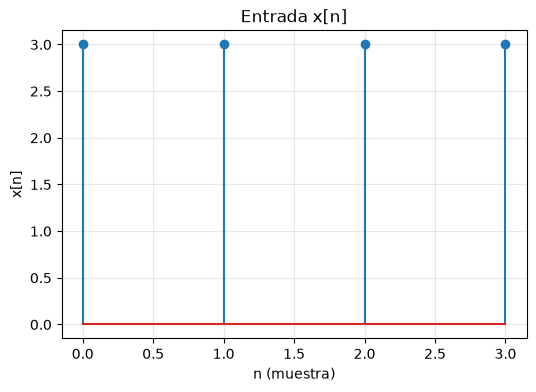

Figura guardada en: src/dft_linea_continua.png


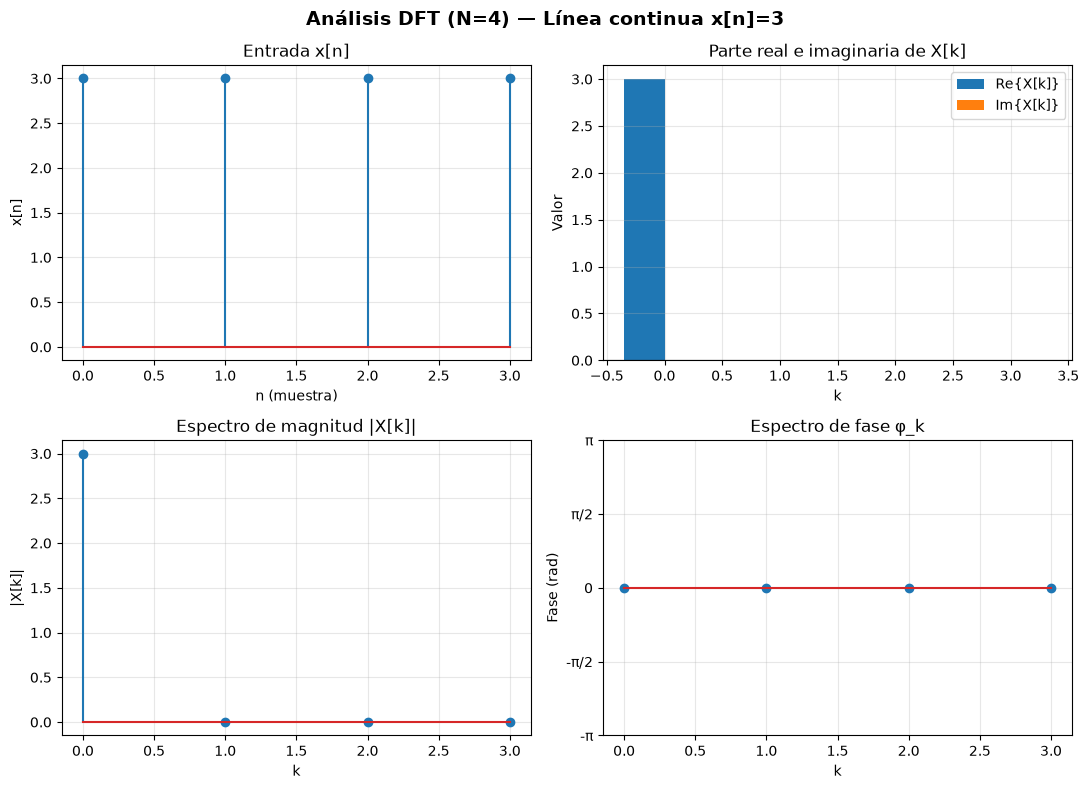

In [3]:
# ------------------------------------------------------------------
# Caso 1: Línea continua x[n] = 3, 3, 3, 3  (del documento)
# ------------------------------------------------------------------
x_continua = [3, 3, 3, 3]
imprimir_resultados(x_continua, "Línea continua")
graficar_dft(x_continua, titulo="Línea continua x[n]=3",
                nombre_archivo="dft_linea_continua.png")
plt.show()



## Senoidal


=== Senoidal de 4 puntos ===
x[n] = [ 0  1  0 -1]
  X[0] = +0.0000 +0.0000j   | |X[0]| = 0.0000   ∠ +0.0000 rad (+0.0°)
  X[1] = +0.0000 -2.0000j   | |X[1]| = 2.0000   ∠ -1.5708 rad (-90.0°)
  X[2] = +0.0000 +0.0000j   | |X[2]| = 0.0000   ∠ +1.5708 rad (+90.0°)
  X[3] = +0.0000 +2.0000j   | |X[3]| = 2.0000   ∠ +1.5708 rad (+90.0°)
[Senoidal x[n]=[0,1,0,-1]] Error máximo vs numpy.fft: 1.50e+00


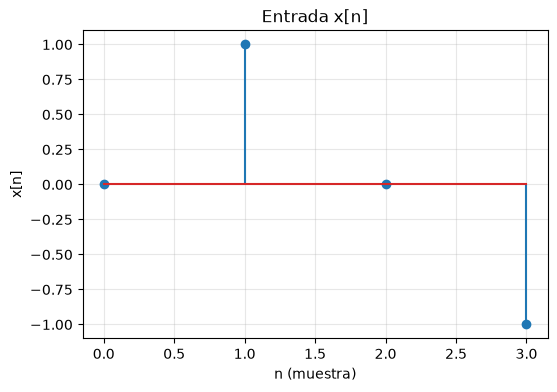

Figura guardada en: src/dft_senoidal_4pts.png

=== Pulso Cuadrado de 4 puntos ===
x[n] = [0 3 3 0]
  X[0] = +6.0000 +0.0000j   | |X[0]| = 6.0000   ∠ +0.0000 rad (+0.0°)
  X[1] = -3.0000 -3.0000j   | |X[1]| = 4.2426   ∠ -2.3562 rad (-135.0°)
  X[2] = +0.0000 +0.0000j   | |X[2]| = 0.0000   ∠ +1.5708 rad (+90.0°)
  X[3] = -3.0000 +3.0000j   | |X[3]| = 4.2426   ∠ +2.3562 rad (+135.0°)
[Pulso Cuadrado x[n]=[0,3,3,0]] Error máximo vs numpy.fft: 4.50e+00


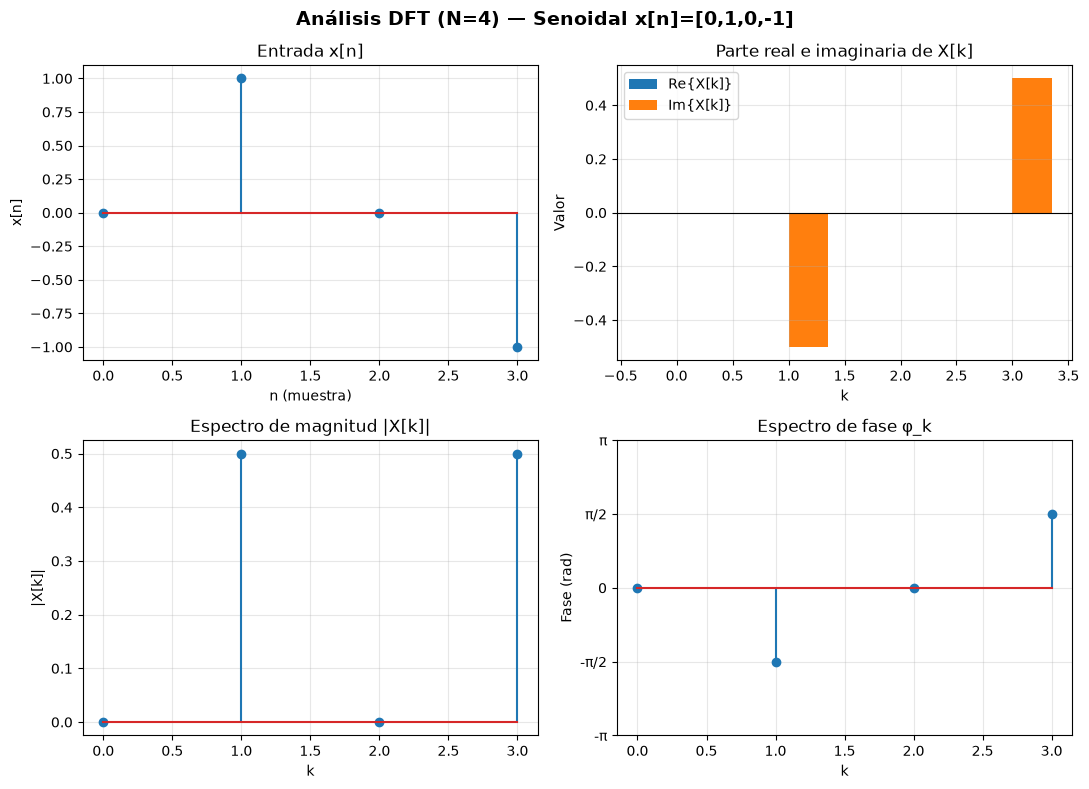

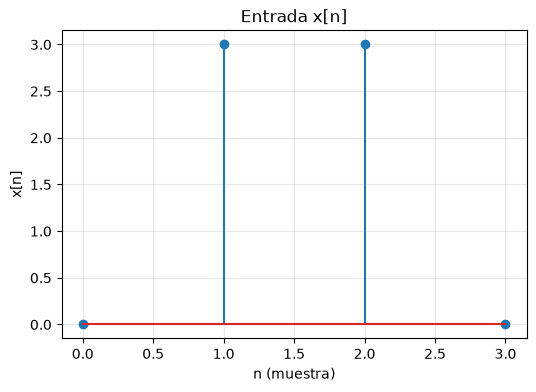

Figura guardada en: src/dft_pulso_4pts.png


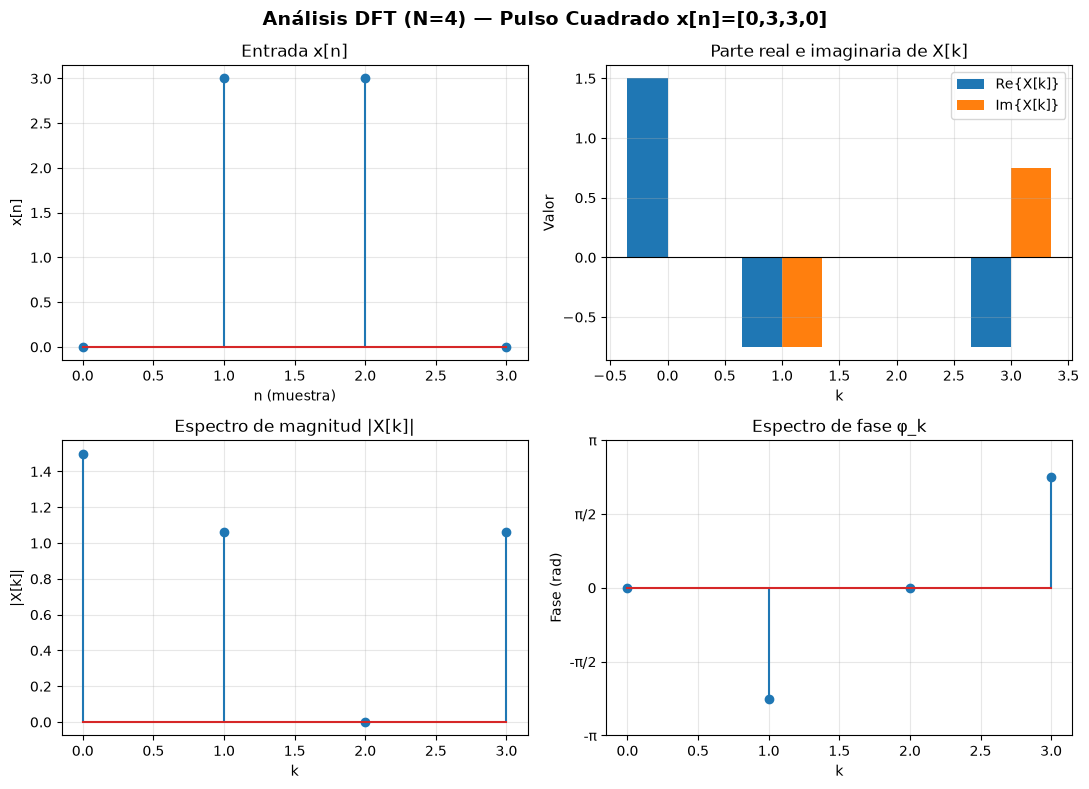

In [7]:
# ------------------------------------------------------------------
# Caso 2: Senoidal de 4 puntos x[n] = 0, 1, 0, -1  (del documento)
# ------------------------------------------------------------------
x_senoidal = [0, 1, 0, -1]
imprimir_resultados(x_senoidal, "Senoidal de 4 puntos")
graficar_dft(x_senoidal, titulo="Senoidal x[n]=[0,1,0,-1]",
                nombre_archivo="dft_senoidal_4pts.png")

x =[0, 3, 3 ,0]
imprimir_resultados(x, "Pulso Cuadrado de 4 puntos")
graficar_dft(x, titulo="Pulso Cuadrado x[n]=[0,3,3,0]",
                nombre_archivo="dft_pulso_4pts.png")

plt.show()